# YZM304 Derin Öğrenme — I. Proje Ödevi
## Pima Indians Diabetes: MLP ile İkili Sınıflandırma

**Ders:** YZM304 Derin Öğrenme | Ankara Üniversitesi  
**Dönem:** 2025–2026 Bahar  
**Veri Seti:** Pima Indians Diabetes Database (NIDDK / UCI)

---
### İçindekiler
1. [Kurulum & İmport](#1)
2. [Veri Yükleme ve Analiz](#2)
3. [Veri Ön İşleme ve Bölme](#3)
4. [Model 1 — Lab Modeli (1 Gizli Katman, n_h=8)](#4)
5. [Grid Search — Model Seçimi](#5)
6. [Geniş & Derin Modeller + Regularizasyon](#6)
7. [Veri Miktarı Etkisi](#7)
8. [Sklearn Karşılaştırması](#8)
9. [PyTorch Karşılaştırması](#9)
10. [Tüm Modellerin Karşılaştırması](#10)
11. [ROC Eğrisi ve AUC Skoru](#11)
12. [Mini-batch SGD Karşılaştırması](#12)


---
<a id='1'></a>
## 1. Kurulum & İmport

In [1]:
import sys, os
# Repo kökünü Python yoluna ekle (src/ paketini bulmak için)
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Proje modülleri
from src.config        import *
from src.data_loader   import load_data, run_eda, preprocess, split_and_scale
from src.models_numpy  import MLP_1Hidden, MLP_2Hidden
from src.models_sklearn import build_sklearn_model, train_and_evaluate_sklearn
from src.models_pytorch import (PyTorchMLP_1Hidden, PyTorchMLP_2Hidden,
                                train_pytorch, plot_pytorch_curve,
                                pt_predict, to_tensor)
from src.evaluate      import (evaluate_model, plot_overfit_summary,
                               plot_comparison_bar, plot_data_fraction_experiment)

np.random.seed(RANDOM_SEED)
print('Tüm modüller yüklendi.')
print(f'RANDOM_SEED={RANDOM_SEED} | TEST={TEST_SIZE} | DEV={DEV_SIZE}')

from sklearn.metrics import accuracy_score


Tüm modüller yüklendi.
RANDOM_SEED=42 | TEST=0.15 | DEV=0.15


---
<a id='2'></a>
## 2. Veri Yükleme ve Analiz

In [2]:
df = load_data()   # data/diabetes.csv → otomatik bulur
df.head(10)


Veri yüklendi: data\diabetes.csv  →  768 satır, 9 sütun


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


=== İstatistiksel Özet ===
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin      BMI  \
count      768.000  768.000        768.000        768.000  768.000  768.000   
mean         3.845  120.895         69.105         20.536   79.799   31.993   
std          3.370   31.973         19.356         15.952  115.244    7.884   
min          0.000    0.000          0.000          0.000    0.000    0.000   
25%          1.000   99.000         62.000          0.000    0.000   27.300   
50%          3.000  117.000         72.000         23.000   30.500   32.000   
75%          6.000  140.250         80.000         32.000  127.250   36.600   
max         17.000  199.000        122.000         99.000  846.000   67.100   

       DiabetesPedigreeFunction      Age  Outcome  
count                   768.000  768.000  768.000  
mean                      0.472   33.241    0.349  
std                       0.331   11.760    0.477  
min                       0.078   21.000    0.000  
2

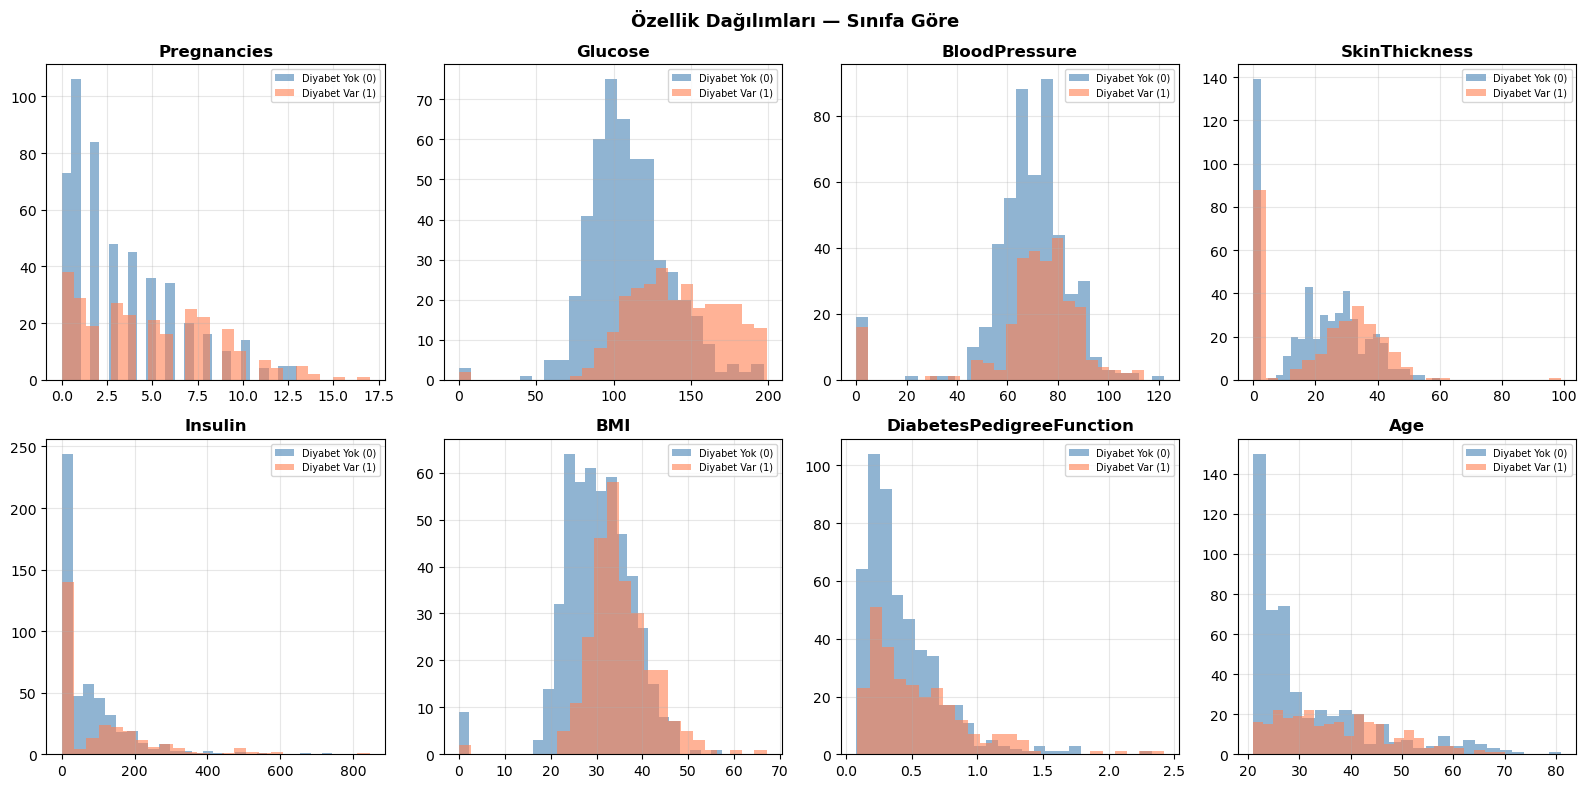

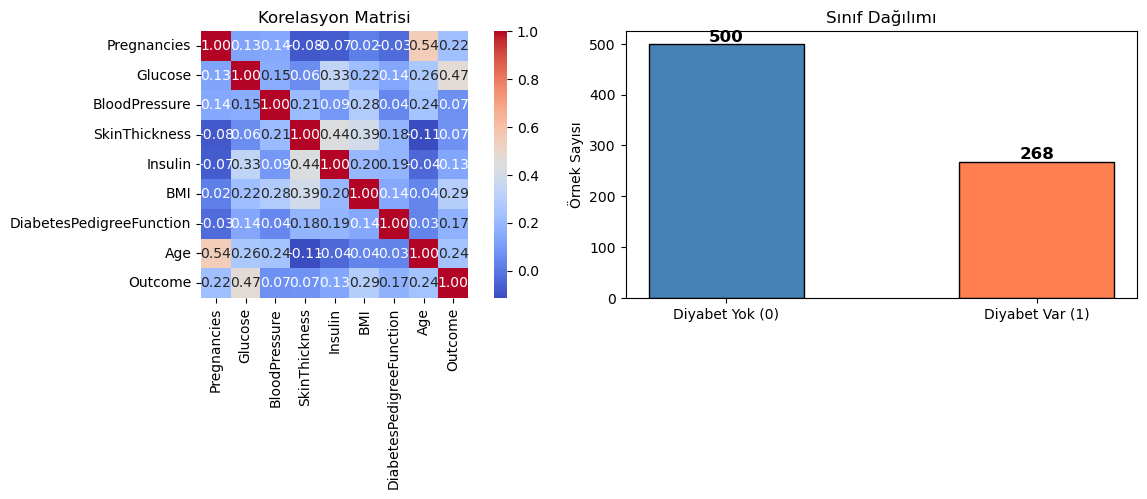

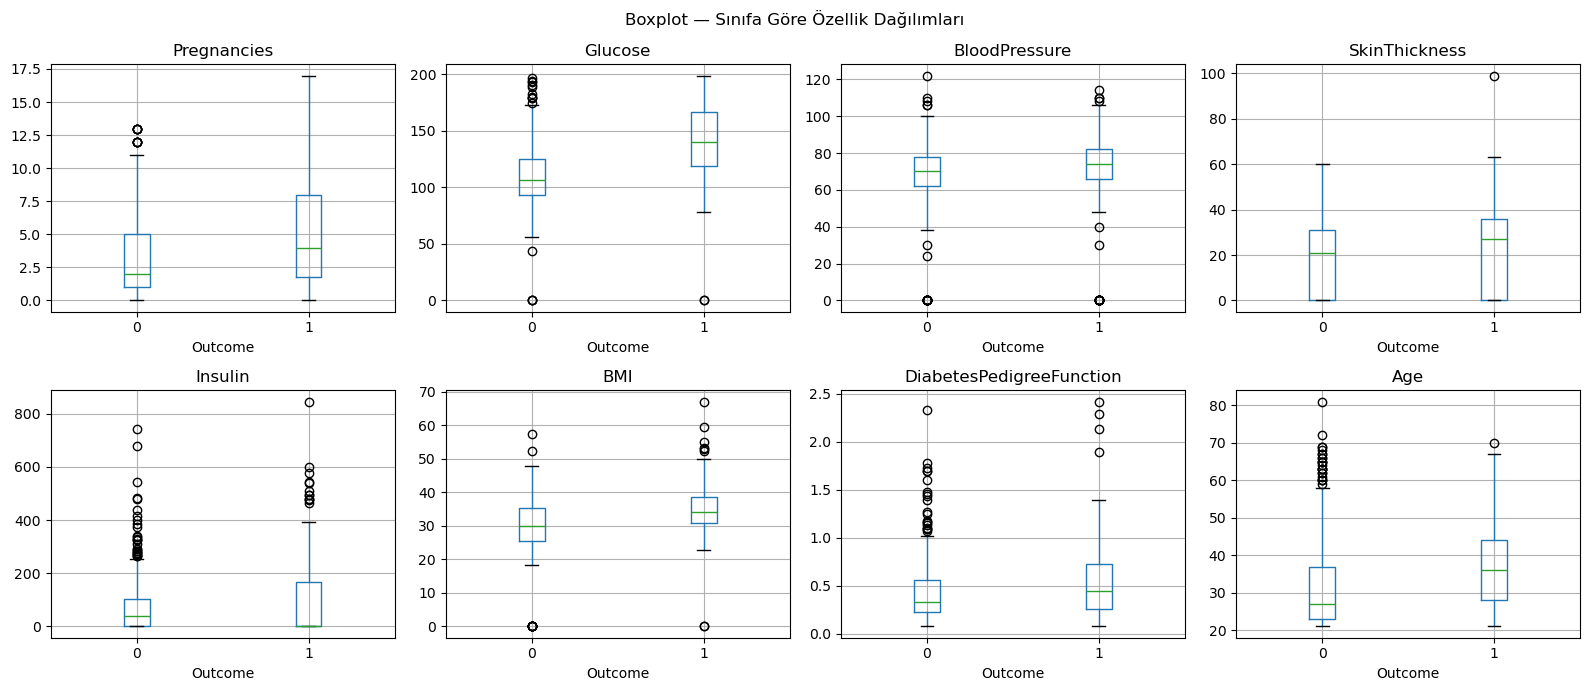

In [3]:
run_eda(df)


---
<a id='3'></a>
## 3. Veri Ön İşleme ve Bölme

1. Biyolojik sıfırları medyan ile doldurma  
2. Karıştırma (`random_state=42`)  
3. Train %70 / Dev %15 / Test %15 (stratified)  
4. StandardScaler — yalnızca train üzerinde `fit`


In [4]:
X, y = preprocess(df)

X_train_s, X_dev_s, X_test_s, \
y_train, y_dev, y_test, scaler = split_and_scale(X, y)


  Glucose                       : 5 sıfır → medyan 117.00 ile değiştirildi
  BloodPressure                 : 35 sıfır → medyan 72.00 ile değiştirildi
  SkinThickness                 : 227 sıfır → medyan 29.00 ile değiştirildi
  Insulin                       : 374 sıfır → medyan 125.00 ile değiştirildi
  BMI                           : 11 sıfır → medyan 32.30 ile değiştirildi

X shape: (768, 8)  |  y shape: (768, 1)
Train: 537  |  Dev: 115  |  Test: 116
  Train: {np.int64(0): np.int64(350), np.int64(1): np.int64(187)}
  Dev: {np.int64(0): np.int64(75), np.int64(1): np.int64(40)}
  Test: {np.int64(0): np.int64(75), np.int64(1): np.int64(41)}
Standardizasyon tamamlandı.


---
<a id='4'></a>
## 4. Model 1 — Lab Modeli (1 Gizli Katman)
**Mimari:** `Input(8) → Dense(8, tanh) → Output(1, sigmoid)`


  Adım     0 | Train Loss: 0.693257 | Val Loss: 0.690966
  Adım   200 | Train Loss: 0.486707 | Val Loss: 0.433895
  Adım   400 | Train Loss: 0.474780 | Val Loss: 0.422044
  Adım   600 | Train Loss: 0.469839 | Val Loss: 0.421911
  Adım   800 | Train Loss: 0.465052 | Val Loss: 0.419091


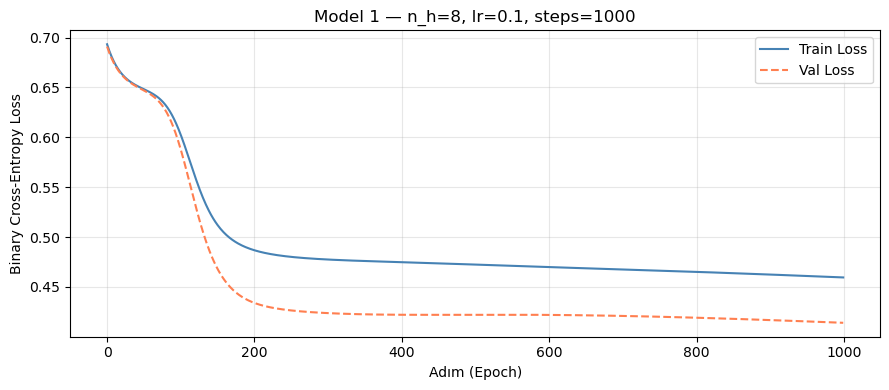

In [5]:
model1 = MLP_1Hidden(
    n_x=X_train_s.shape[1], n_h=N_H_1, n_y=1,
    learning_rate=LR_1, n_steps=STEPS_1,
    hidden_activation='tanh', l2_lambda=0.0,
    print_cost=True, print_every=200
)
model1.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)
model1.plot_learning_curve('Model 1 — n_h=8, lr=0.1, steps=1000')


Train: 0.7840 | Dev: 0.8261 | Test: 0.7586 | Fark: -0.0421
>>> Makul denge

  NumPy M1 — n_h=8
  Accuracy : 0.7586
  Precision: 0.6857
  Recall   : 0.5854
  F1 Score : 0.6316

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7901    0.8533    0.8205        75
Diyabet Var (1)     0.6857    0.5854    0.6316        41

       accuracy                         0.7586       116
      macro avg     0.7379    0.7193    0.7260       116
   weighted avg     0.7532    0.7586    0.7537       116



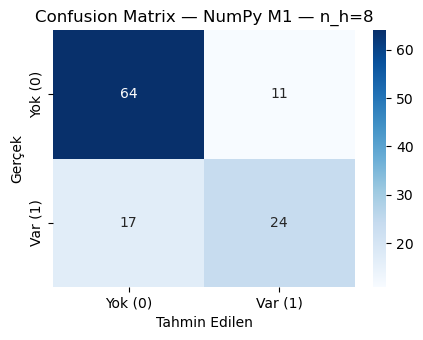

In [6]:
tr1 = model1.score(X_train_s, y_train)
dv1 = model1.score(X_dev_s,   y_dev)
ts1 = model1.score(X_test_s,  y_test)
gap = tr1 - dv1
print(f'Train: {tr1:.4f} | Dev: {dv1:.4f} | Test: {ts1:.4f} | Fark: {gap:.4f}')
if   tr1 < 0.75: print('>>> YÜKSEK BIAS (Underfitting)')
elif gap > 0.05: print('>>> YÜKSEK VARYANS (Overfitting)')
else:            print('>>> Makul denge')

_ = evaluate_model('NumPy M1 — n_h=8', y_test.flatten(), model1.predict(X_test_s))


---
<a id='5'></a>
## 5. Grid Search — Model Seçimi

**Kriter:** Dev accuracy ≥ %75 olan modeller arasından `n_steps` en düşük olanı seç.  
**Test seti grid search sırasında kullanılmaz** (data leakage önlemi).


In [7]:
results = []
print('Grid search (yalnızca train & dev kullanılıyor)...')
for n_h in GRID_NH_VALUES:
    for n_step in GRID_STEP_VALUES:
        m = MLP_1Hidden(n_x=X_train_s.shape[1], n_h=n_h, n_y=1,
                        learning_rate=0.1, n_steps=n_step,
                        hidden_activation='tanh', l2_lambda=0.0)
        m.fit(X_train_s, y_train)
        results.append({'n_h': n_h, 'n_steps': n_step,
                        'train_acc': m.score(X_train_s, y_train),
                        'dev_acc':   m.score(X_dev_s,   y_dev)})

results_df = pd.DataFrame(results)
print('Tamamlandı.')
results_df.sort_values('dev_acc', ascending=False).head(10)


Grid search (yalnızca train & dev kullanılıyor)...
Tamamlandı.


,n_h,n_steps,train_acc,dev_acc
22,10,1000,0.776536,0.826087
16,8,1000,0.783985,0.826087
9,6,800,0.770950,0.826087
10,6,1000,0.789572,0.826087
28,12,1000,0.776536,0.826087
34,16,1000,0.772812,0.817391
33,16,800,0.772812,0.817391
3,4,800,0.778399,0.817391
27,12,800,0.770950,0.817391
21,10,800,0.776536,0.817391


Seçilen Model → n_h=4, n_steps=200
Train: 0.7616 | Dev: 0.8000


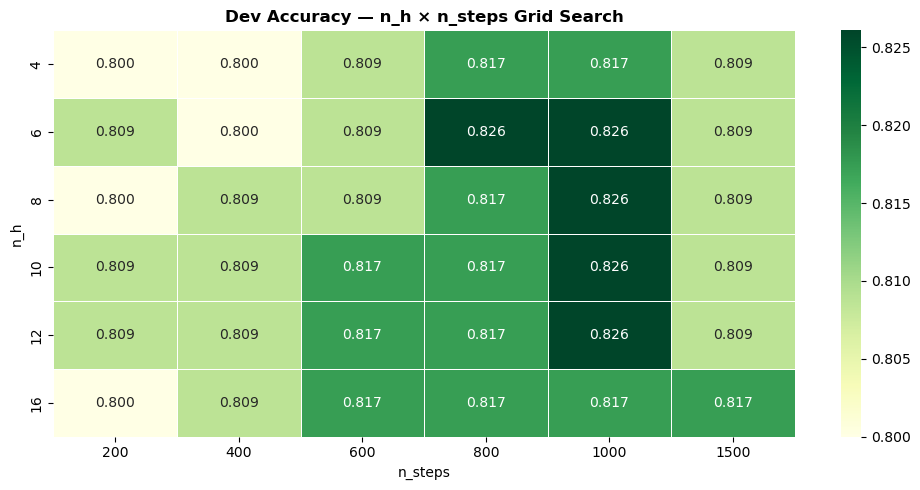

In [8]:
import seaborn as sns
filtered = results_df[results_df['dev_acc'] >= GRID_THRESHOLD]
if len(filtered) > 0:
    best_row = filtered.sort_values('n_steps').iloc[0]
else:
    print(f'Eşik ({GRID_THRESHOLD}) geçilemedi; en iyi dev_acc modeli seçiliyor.')
    best_row = results_df.sort_values('dev_acc', ascending=False).iloc[0]

BEST_NH    = int(best_row['n_h'])
BEST_STEPS = int(best_row['n_steps'])
print(f'Seçilen Model → n_h={BEST_NH}, n_steps={BEST_STEPS}')
print(f'Train: {best_row["train_acc"]:.4f} | Dev: {best_row["dev_acc"]:.4f}')

# Heatmap
pivot = results_df.pivot(index='n_h', columns='n_steps', values='dev_acc')
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Dev Accuracy — n_h × n_steps Grid Search', fontweight='bold')
plt.tight_layout(); plt.show()


---
<a id='6'></a>
## 6. Geniş & Derin Modeller + Regularizasyon

| Model | Mimari | L2 |
|-------|--------|----|
| M2 | 8 → 32 → 1 | — |
| M3 | 8 → 32 → 1 | λ=0.01 |
| M4 | 8 → 16 → 8 → 1 | — |
| M5 | 8 → 16 → 8 → 1 | λ=0.01 |


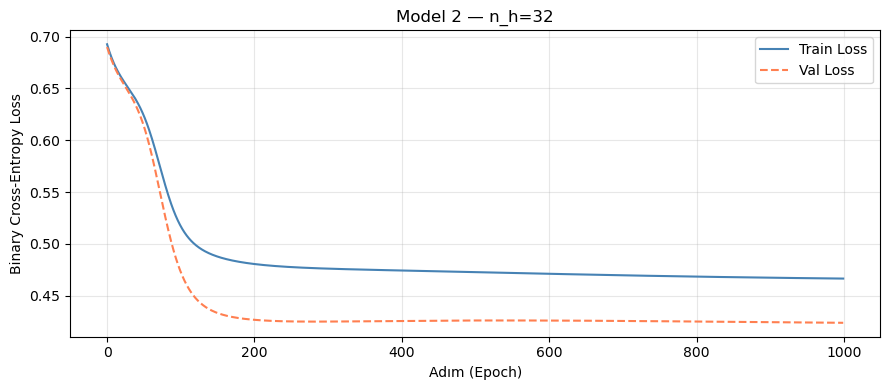

Train:0.7747 Dev:0.8087 Fark:-0.0340  >>> Makul

  M2 — n_h=32
  Accuracy : 0.7672
  Precision: 0.7059
  Recall   : 0.5854
  F1 Score : 0.6400

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7927    0.8667    0.8280        75
Diyabet Var (1)     0.7059    0.5854    0.6400        41

       accuracy                         0.7672       116
      macro avg     0.7493    0.7260    0.7340       116
   weighted avg     0.7620    0.7672    0.7616       116



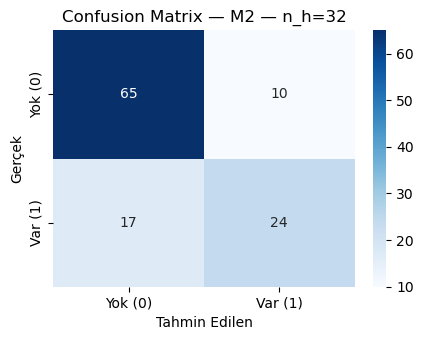

In [9]:
# Model 2 — Geniş (n_h=32)
model2 = MLP_1Hidden(n_x=X_train_s.shape[1], n_h=N_H_2, n_y=1,
                     learning_rate=LEARNING_RATE, n_steps=N_STEPS,
                     hidden_activation='tanh', l2_lambda=0.0)
model2.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)
model2.plot_learning_curve('Model 2 — n_h=32')
t2, d2 = model2.score(X_train_s,y_train), model2.score(X_dev_s,y_dev)
print(f'Train:{t2:.4f} Dev:{d2:.4f} Fark:{t2-d2:.4f}  >>> {"Overfitting" if t2-d2>0.05 else "Makul"}')
_ = evaluate_model('M2 — n_h=32', y_test.flatten(), model2.predict(X_test_s))


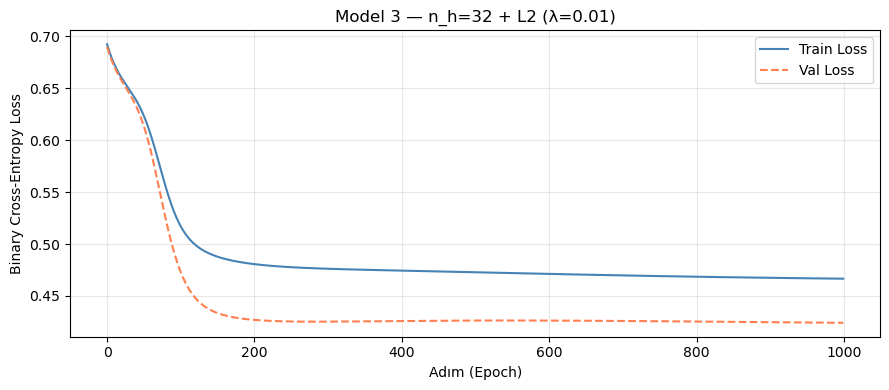

Train:0.7747 Dev:0.8087 Fark:-0.0340  >>> L2 etkisiyle karşılaştır

  M3 — n_h=32 + L2
  Accuracy : 0.7672
  Precision: 0.7059
  Recall   : 0.5854
  F1 Score : 0.6400

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7927    0.8667    0.8280        75
Diyabet Var (1)     0.7059    0.5854    0.6400        41

       accuracy                         0.7672       116
      macro avg     0.7493    0.7260    0.7340       116
   weighted avg     0.7620    0.7672    0.7616       116



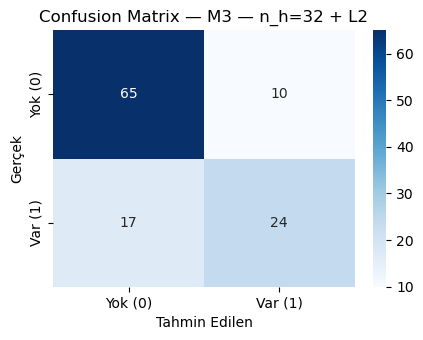

In [10]:
# Model 3 — Geniş + L2
model3 = MLP_1Hidden(n_x=X_train_s.shape[1], n_h=N_H_3, n_y=1,
                     learning_rate=LEARNING_RATE, n_steps=N_STEPS,
                     hidden_activation='tanh', l2_lambda=L2_LAMBDA_3)
model3.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)
model3.plot_learning_curve('Model 3 — n_h=32 + L2 (λ=0.01)')
t3, d3 = model3.score(X_train_s,y_train), model3.score(X_dev_s,y_dev)
print(f'Train:{t3:.4f} Dev:{d3:.4f} Fark:{t3-d3:.4f}  >>> L2 etkisiyle karşılaştır')
_ = evaluate_model('M3 — n_h=32 + L2', y_test.flatten(), model3.predict(X_test_s))


  Adım     0 | Loss: 0.693151 | Val: 0.690866


  Adım   200 | Loss: 0.646334 | Val: 0.646076
  Adım   400 | Loss: 0.646291 | Val: 0.646020
  Adım   600 | Loss: 0.646100 | Val: 0.645776
  Adım   800 | Loss: 0.642258 | Val: 0.640839


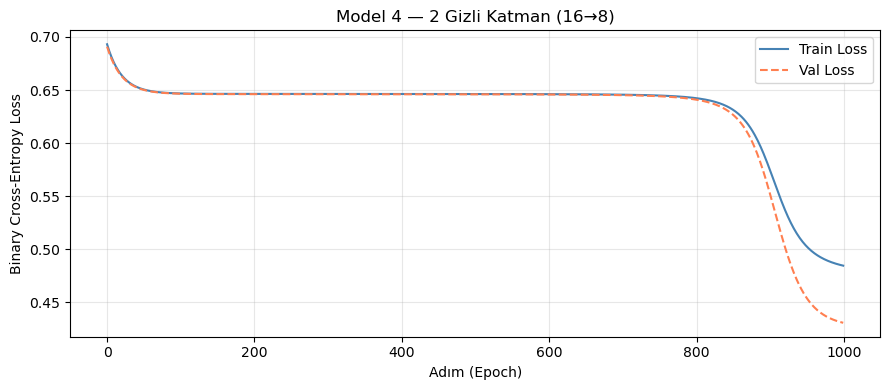

Train:0.7616 Dev:0.8087 Fark:-0.0471

  M4 — 16→8
  Accuracy : 0.7500
  Precision: 0.6765
  Recall   : 0.5610
  F1 Score : 0.6133

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7805    0.8533    0.8153        75
Diyabet Var (1)     0.6765    0.5610    0.6133        41

       accuracy                         0.7500       116
      macro avg     0.7285    0.7072    0.7143       116
   weighted avg     0.7437    0.7500    0.7439       116



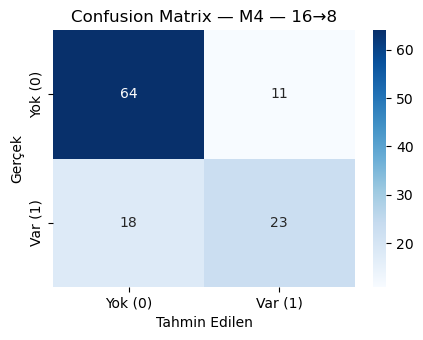

In [11]:
# Model 4 — 2 Gizli Katman
model4 = MLP_2Hidden(n_x=X_train_s.shape[1], n_h1=N_H1_4, n_h2=N_H2_4, n_y=1,
                     learning_rate=LEARNING_RATE, n_steps=N_STEPS, l2_lambda=0.0,
                     print_cost=True, print_every=200)
model4.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)
model4.plot_learning_curve('Model 4 — 2 Gizli Katman (16→8)')
t4, d4 = model4.score(X_train_s,y_train), model4.score(X_dev_s,y_dev)
print(f'Train:{t4:.4f} Dev:{d4:.4f} Fark:{t4-d4:.4f}')
_ = evaluate_model('M4 — 16→8', y_test.flatten(), model4.predict(X_test_s))


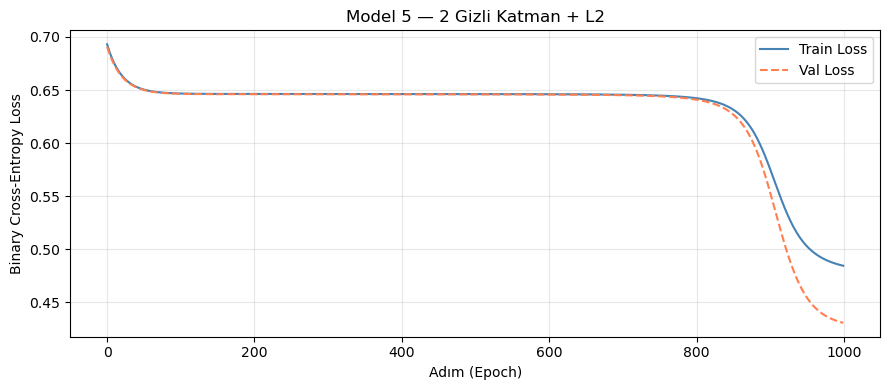

Train:0.7616 Dev:0.8087 Fark:-0.0471

  M5 — 16→8 + L2
  Accuracy : 0.7500
  Precision: 0.6765
  Recall   : 0.5610
  F1 Score : 0.6133

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7805    0.8533    0.8153        75
Diyabet Var (1)     0.6765    0.5610    0.6133        41

       accuracy                         0.7500       116
      macro avg     0.7285    0.7072    0.7143       116
   weighted avg     0.7437    0.7500    0.7439       116



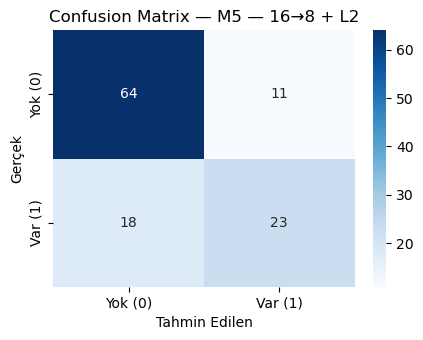

In [12]:
# Model 5 — 2 Gizli Katman + L2
model5 = MLP_2Hidden(n_x=X_train_s.shape[1], n_h1=N_H1_5, n_h2=N_H2_5, n_y=1,
                     learning_rate=LEARNING_RATE, n_steps=N_STEPS, l2_lambda=L2_LAMBDA_5)
model5.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)
model5.plot_learning_curve('Model 5 — 2 Gizli Katman + L2')
t5, d5 = model5.score(X_train_s,y_train), model5.score(X_dev_s,y_dev)
print(f'Train:{t5:.4f} Dev:{d5:.4f} Fark:{t5-d5:.4f}')
_ = evaluate_model('M5 — 16→8 + L2', y_test.flatten(), model5.predict(X_test_s))


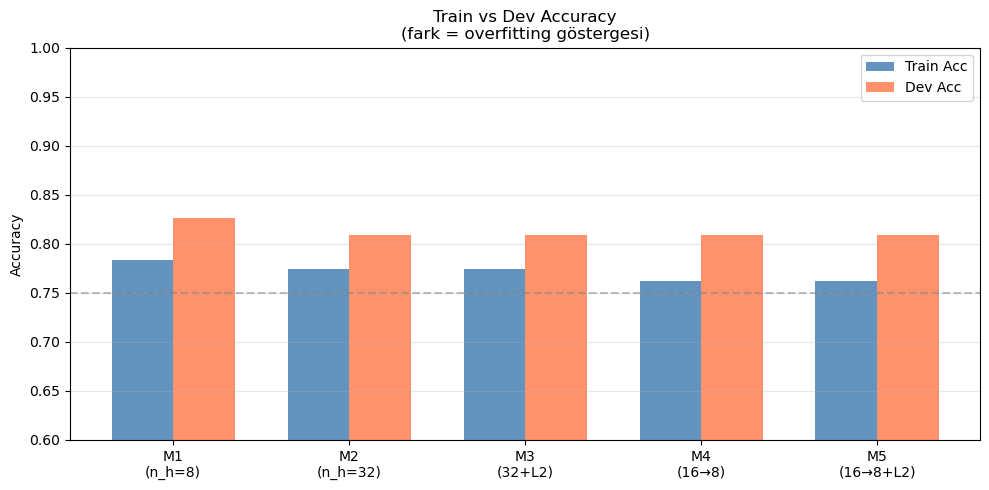

In [13]:
# Overfitting / Underfitting özet grafiği
plot_overfit_summary(
    model_names=['M1\n(n_h=8)', 'M2\n(n_h=32)', 'M3\n(32+L2)',
                 'M4\n(16→8)',  'M5\n(16→8+L2)'],
    train_accs=[model1.score(X_train_s,y_train), model2.score(X_train_s,y_train),
                model3.score(X_train_s,y_train), model4.score(X_train_s,y_train),
                model5.score(X_train_s,y_train)],
    dev_accs  =[model1.score(X_dev_s,y_dev), model2.score(X_dev_s,y_dev),
                model3.score(X_dev_s,y_dev), model4.score(X_dev_s,y_dev),
                model5.score(X_dev_s,y_dev)],
    threshold=GRID_THRESHOLD
)


---
<a id='7'></a>
## 7. Veri Miktarı Etkisi

Grid search ile seçilen en iyi model `%50`, `%75` ve `%100` train verisiyle eğitilir.  
**Amaç:** daha az veriyle modelin nasıl davrandığını gözlemlemek.  
**Önemli:** Dev ve test setleri sabit kalır — yalnızca train alt-kümesi değişir.


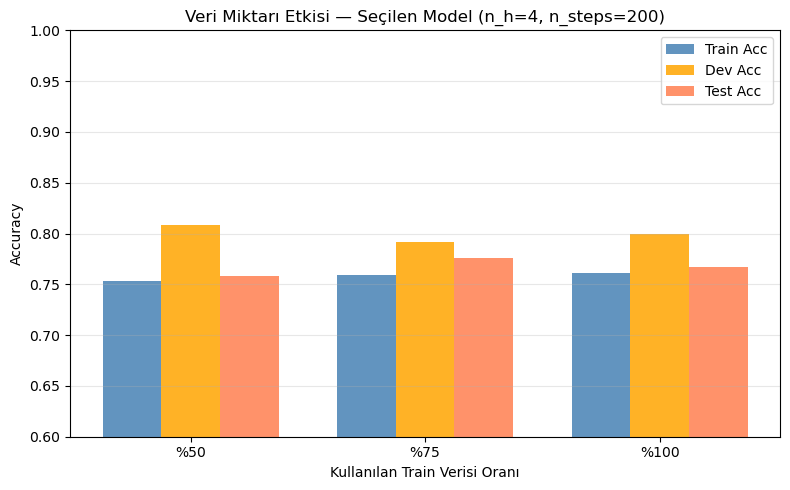


Oran        Train      Dev     Test
------------------------------------
%50        0.7537   0.8087   0.7586
%75        0.7587   0.7913   0.7759
%100       0.7616   0.8000   0.7672


In [14]:
frac_train_accs, frac_dev_accs, frac_test_accs = [], [], []

for frac in DATA_FRACTIONS:
    n_samples = int(len(X_train_s) * frac)
    X_tr_sub = X_train_s[:n_samples]
    y_tr_sub = y_train[:n_samples]

    m = MLP_1Hidden(
        n_x=X_tr_sub.shape[1], n_h=BEST_NH, n_y=1,
        learning_rate=LEARNING_RATE, n_steps=BEST_STEPS,
        hidden_activation='tanh', l2_lambda=0.0
    )
    m.fit(X_tr_sub, y_tr_sub)

    frac_train_accs.append(m.score(X_tr_sub,  y_tr_sub))
    frac_dev_accs.append(  m.score(X_dev_s,   y_dev))
    frac_test_accs.append( m.score(X_test_s,  y_test))

plot_data_fraction_experiment(
    DATA_FRACTIONS, frac_train_accs, frac_dev_accs, frac_test_accs,
    model_label=f'Seçilen Model (n_h={BEST_NH}, n_steps={BEST_STEPS})'
)


---
<a id='8'></a>
## 8. Sklearn MLPClassifier — Framework Karşılaştırması

Aynı mimari, aynı SGD (momentum=0, tam-batch), aynı `random_state=42`.


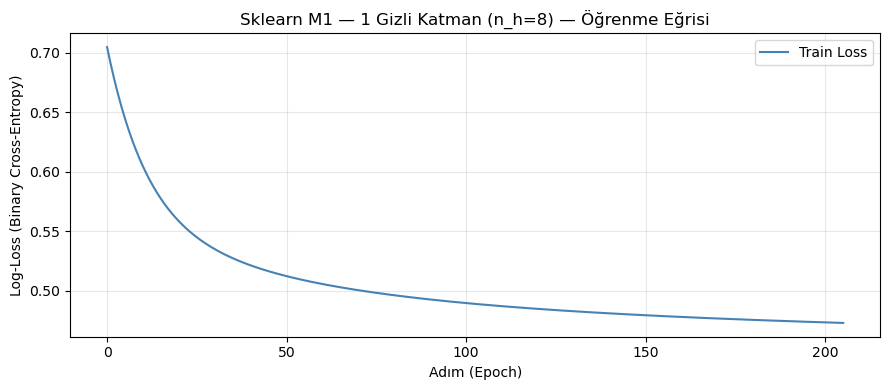

Sklearn M1 — 1 Gizli Katman (n_h=8) | Train: 0.7784 | Dev: 0.7913 | Test: 0.7672

  Sklearn M1
  Accuracy : 0.7672
  Precision: 0.7059
  Recall   : 0.5854
  F1 Score : 0.6400

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7927    0.8667    0.8280        75
Diyabet Var (1)     0.7059    0.5854    0.6400        41

       accuracy                         0.7672       116
      macro avg     0.7493    0.7260    0.7340       116
   weighted avg     0.7620    0.7672    0.7616       116



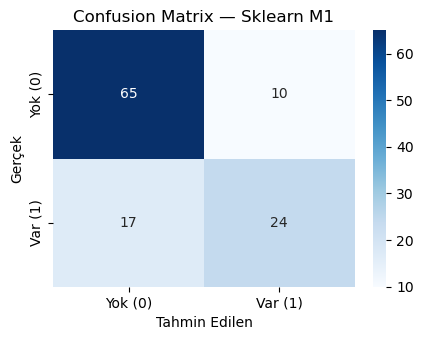

In [15]:
sk_m1 = build_sklearn_model(
    hidden_layer_sizes=(N_H_1,),
    learning_rate=LR_1, n_steps=STEPS_1,
    batch_size=X_train_s.shape[0]
)
sk1_res = train_and_evaluate_sklearn(
    sk_m1, X_train_s, y_train, X_dev_s, y_dev, X_test_s, y_test,
    model_name='Sklearn M1 — 1 Gizli Katman (n_h=8)'
)
_ = evaluate_model('Sklearn M1', y_test.flatten(), sk_m1.predict(X_test_s))


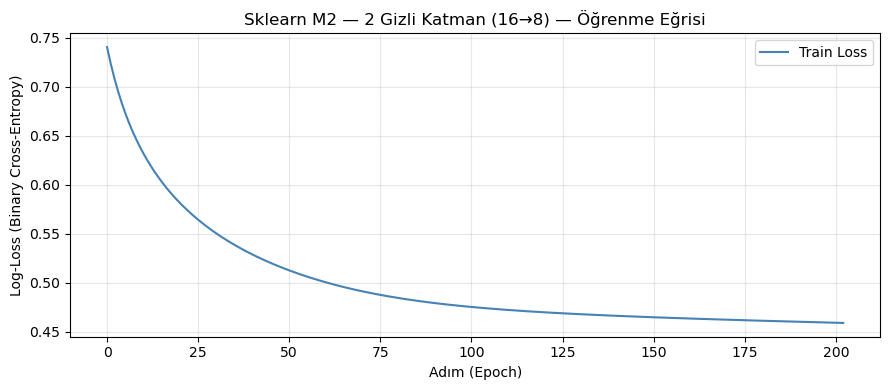

Sklearn M2 — 2 Gizli Katman (16→8) | Train: 0.7858 | Dev: 0.7913 | Test: 0.7586

  Sklearn M2
  Accuracy : 0.7586
  Precision: 0.6857
  Recall   : 0.5854
  F1 Score : 0.6316

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7901    0.8533    0.8205        75
Diyabet Var (1)     0.6857    0.5854    0.6316        41

       accuracy                         0.7586       116
      macro avg     0.7379    0.7193    0.7260       116
   weighted avg     0.7532    0.7586    0.7537       116



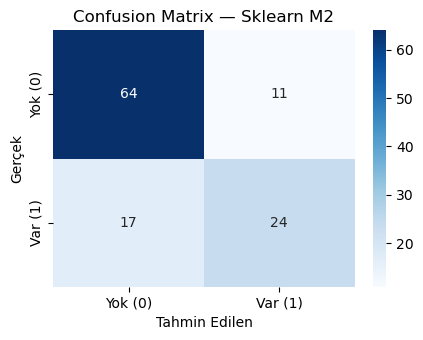

In [16]:
sk_m2 = build_sklearn_model(
    hidden_layer_sizes=(N_H1_4, N_H2_4),
    learning_rate=LEARNING_RATE, n_steps=N_STEPS,
    batch_size=X_train_s.shape[0]
)
sk2_res = train_and_evaluate_sklearn(
    sk_m2, X_train_s, y_train, X_dev_s, y_dev, X_test_s, y_test,
    model_name='Sklearn M2 — 2 Gizli Katman (16→8)'
)
_ = evaluate_model('Sklearn M2', y_test.flatten(), sk_m2.predict(X_test_s))


---
<a id='9'></a>
## 9. PyTorch MLP — Framework Karşılaştırması


In [17]:
import torch
torch.manual_seed(RANDOM_SEED)
print(f'PyTorch {torch.__version__}')

Xtr = to_tensor(X_train_s); ytr = to_tensor(y_train)
Xdv = to_tensor(X_dev_s);   ydv = to_tensor(y_dev)
Xts = to_tensor(X_test_s);  yts = to_tensor(y_test)


PyTorch 2.11.0+cpu


PyTorchMLP_1Hidden(
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


  Adım     0 | Train: 0.693221 | Val: 0.690956
  Adım   200 | Train: 0.487259 | Val: 0.434510
  Adım   400 | Train: 0.475016 | Val: 0.422173
  Adım   600 | Train: 0.471275 | Val: 0.421742
  Adım   800 | Train: 0.467792 | Val: 0.419603


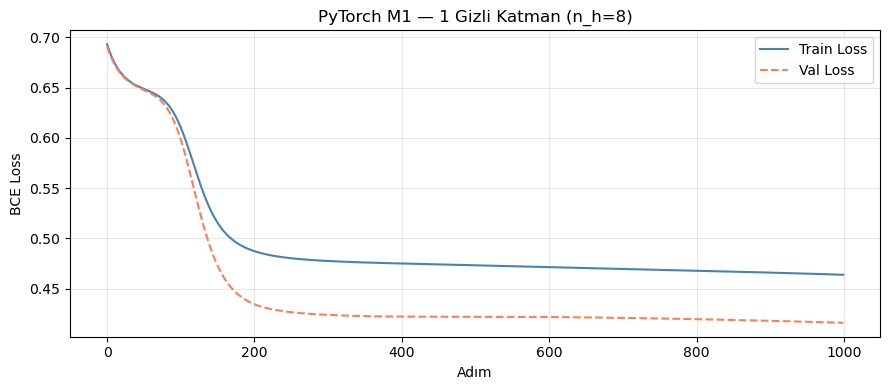

PyTorch M1 | Train:0.7765 Dev:0.8174 Test:0.7672

  PyTorch M1
  Accuracy : 0.7672
  Precision: 0.7059
  Recall   : 0.5854
  F1 Score : 0.6400

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7927    0.8667    0.8280        75
Diyabet Var (1)     0.7059    0.5854    0.6400        41

       accuracy                         0.7672       116
      macro avg     0.7493    0.7260    0.7340       116
   weighted avg     0.7620    0.7672    0.7616       116



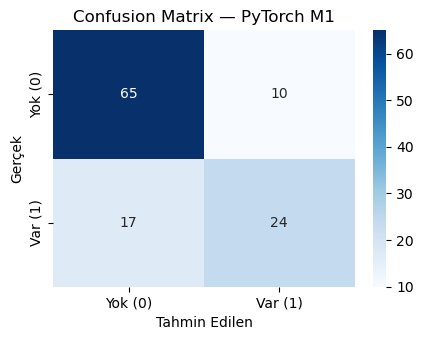

In [18]:
from sklearn.metrics import accuracy_score
pt1 = PyTorchMLP_1Hidden(n_x=X_train_s.shape[1], n_h=N_H_1)
print(pt1)
pt1_cost, pt1_val = train_pytorch(pt1, Xtr, ytr, Xdv, ydv,
                                   lr=LR_1, n_steps=STEPS_1, print_every=200)
plot_pytorch_curve(pt1_cost, pt1_val, 'PyTorch M1 — 1 Gizli Katman (n_h=8)')

pt1_tr = accuracy_score(y_train.flatten(), pt_predict(pt1, Xtr))
pt1_dv = accuracy_score(y_dev.flatten(),   pt_predict(pt1, Xdv))
pt1_ts = accuracy_score(y_test.flatten(),  pt_predict(pt1, Xts))
print(f'PyTorch M1 | Train:{pt1_tr:.4f} Dev:{pt1_dv:.4f} Test:{pt1_ts:.4f}')
_ = evaluate_model('PyTorch M1', y_test.flatten(), pt_predict(pt1, Xts))


  Adım     0 | Train: 0.693148 | Val: 0.690863


  Adım   200 | Train: 0.646338 | Val: 0.646081
  Adım   400 | Train: 0.646310 | Val: 0.646043
  Adım   600 | Train: 0.646219 | Val: 0.645923
  Adım   800 | Train: 0.645354 | Val: 0.644802


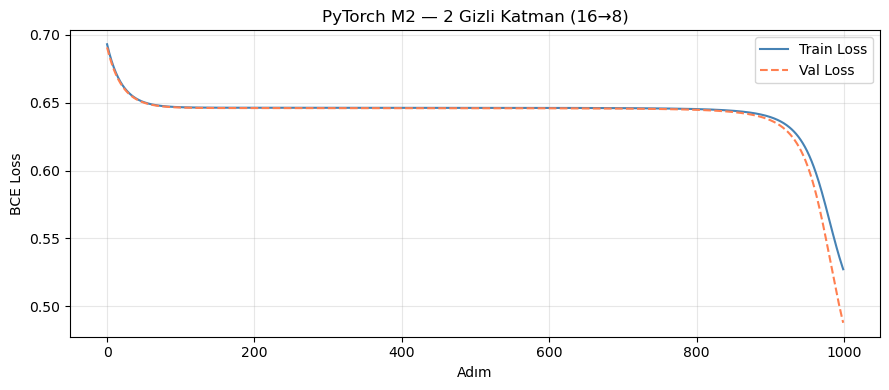

PyTorch M2 | Train:0.7412 Dev:0.7826 Test:0.7672

  PyTorch M2
  Accuracy : 0.7672
  Precision: 0.8500
  Recall   : 0.4146
  F1 Score : 0.5574

                 precision    recall  f1-score   support

Diyabet Yok (0)     0.7500    0.9600    0.8421        75
Diyabet Var (1)     0.8500    0.4146    0.5574        41

       accuracy                         0.7672       116
      macro avg     0.8000    0.6873    0.6997       116
   weighted avg     0.7853    0.7672    0.7415       116



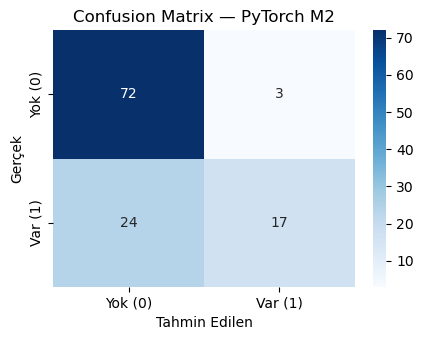

In [19]:
from sklearn.metrics import accuracy_score
pt2 = PyTorchMLP_2Hidden(n_x=X_train_s.shape[1], n_h1=N_H1_4, n_h2=N_H2_4)
pt2_cost, pt2_val = train_pytorch(pt2, Xtr, ytr, Xdv, ydv,
                                   lr=LEARNING_RATE, n_steps=N_STEPS, print_every=200)
plot_pytorch_curve(pt2_cost, pt2_val, 'PyTorch M2 — 2 Gizli Katman (16→8)')

pt2_tr = accuracy_score(y_train.flatten(), pt_predict(pt2, Xtr))
pt2_dv = accuracy_score(y_dev.flatten(),   pt_predict(pt2, Xdv))
pt2_ts = accuracy_score(y_test.flatten(),  pt_predict(pt2, Xts))
print(f'PyTorch M2 | Train:{pt2_tr:.4f} Dev:{pt2_dv:.4f} Test:{pt2_ts:.4f}')
_ = evaluate_model('PyTorch M2', y_test.flatten(), pt_predict(pt2, Xts))


---
<a id='10'></a>
## 10. Tüm Modellerin Karşılaştırması


In [20]:
comparison = pd.DataFrame([
    {'Model': 'NumPy M1 (n_h=8)',      'Framework': 'NumPy',
     'Train': model1.score(X_train_s,y_train),
     'Dev':   model1.score(X_dev_s,y_dev),
     'Test':  model1.score(X_test_s,y_test)},
    {'Model': 'NumPy M2 (n_h=32)',     'Framework': 'NumPy',
     'Train': model2.score(X_train_s,y_train),
     'Dev':   model2.score(X_dev_s,y_dev),
     'Test':  model2.score(X_test_s,y_test)},
    {'Model': 'NumPy M3 (32+L2)',      'Framework': 'NumPy',
     'Train': model3.score(X_train_s,y_train),
     'Dev':   model3.score(X_dev_s,y_dev),
     'Test':  model3.score(X_test_s,y_test)},
    {'Model': 'NumPy M4 (16→8)',       'Framework': 'NumPy',
     'Train': model4.score(X_train_s,y_train),
     'Dev':   model4.score(X_dev_s,y_dev),
     'Test':  model4.score(X_test_s,y_test)},
    {'Model': 'NumPy M5 (16→8+L2)',    'Framework': 'NumPy',
     'Train': model5.score(X_train_s,y_train),
     'Dev':   model5.score(X_dev_s,y_dev),
     'Test':  model5.score(X_test_s,y_test)},
    {'Model': 'Sklearn M1 (n_h=8)',    'Framework': 'Sklearn',
     'Train': sk1_res['train_acc'],
     'Dev':   sk1_res['dev_acc'],
     'Test':  sk1_res['test_acc']},
    {'Model': 'Sklearn M2 (16→8)',     'Framework': 'Sklearn',
     'Train': sk2_res['train_acc'],
     'Dev':   sk2_res['dev_acc'],
     'Test':  sk2_res['test_acc']},
    {'Model': 'PyTorch M1 (n_h=8)',    'Framework': 'PyTorch',
     'Train': pt1_tr, 'Dev': pt1_dv, 'Test': pt1_ts},
    {'Model': 'PyTorch M2 (16→8)',     'Framework': 'PyTorch',
     'Train': pt2_tr, 'Dev': pt2_dv, 'Test': pt2_ts},
])

comparison = comparison.sort_values('Test', ascending=False).reset_index(drop=True)
print('=== Model Karşılaştırma Tablosu ===')
print(comparison.to_string(index=False))


=== Model Karşılaştırma Tablosu ===
             Model Framework    Train      Dev     Test
 NumPy M2 (n_h=32)     NumPy 0.774674 0.808696 0.767241
 PyTorch M2 (16→8)   PyTorch 0.741155 0.782609 0.767241
  NumPy M3 (32+L2)     NumPy 0.774674 0.808696 0.767241
PyTorch M1 (n_h=8)   PyTorch 0.776536 0.817391 0.767241
Sklearn M1 (n_h=8)   Sklearn 0.778399 0.791304 0.767241
  NumPy M1 (n_h=8)     NumPy 0.783985 0.826087 0.758621
 Sklearn M2 (16→8)   Sklearn 0.785847 0.791304 0.758621
NumPy M5 (16→8+L2)     NumPy 0.761639 0.808696 0.750000
   NumPy M4 (16→8)     NumPy 0.761639 0.808696 0.750000


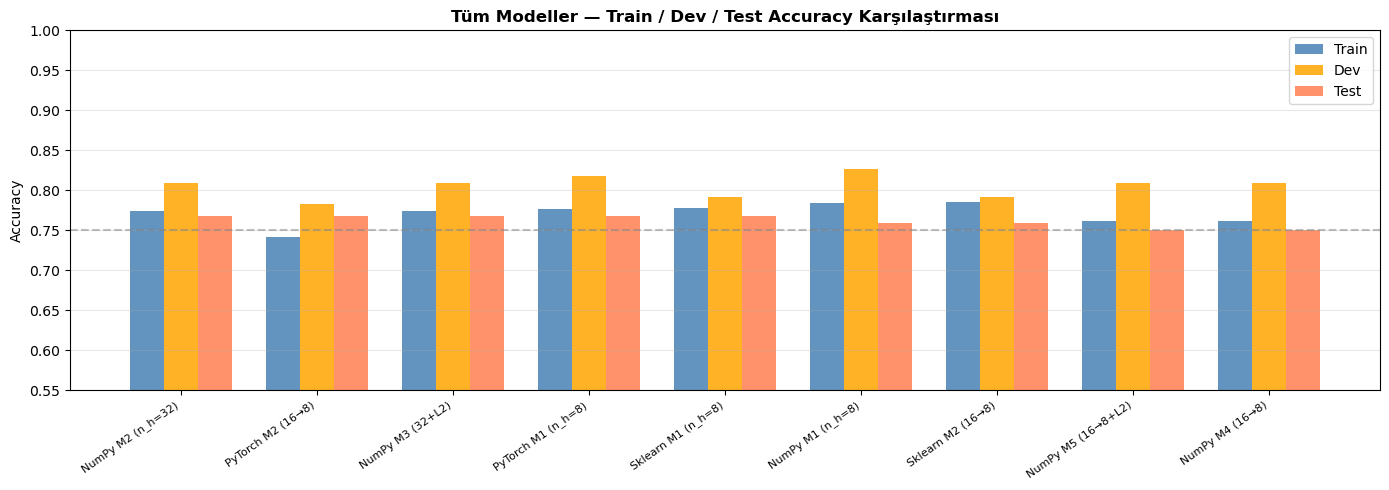

In [21]:
plot_comparison_bar(comparison)


---
<a id='11'></a>
## 11. ROC Eğrisi ve AUC Skoru

Accuracy sınıf dengesizliğinde yanıltıcı olabilir. ROC eğrisi ve AUC, modellerin ayırıcılık gücünü daha iyi yansıtır.



Model                                  AUC
-------------------------------------------
  NumPy M1 (n_h=8)                  0.8550
  NumPy M2 (n_h=32)                 0.8556
  NumPy M4 (16→8)                   0.8582
  Sklearn M1                        0.8624
  PyTorch M1                        0.8537


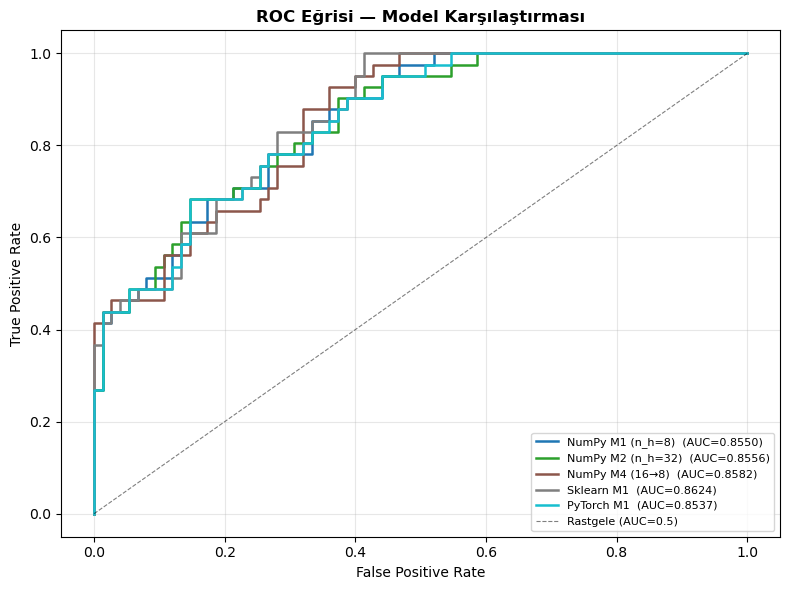

In [22]:
from src.evaluate import plot_roc_auc

roc_models = [
    {'name': 'NumPy M1 (n_h=8)',  'y_proba': model1.predict_proba(X_test_s)},
    {'name': 'NumPy M2 (n_h=32)', 'y_proba': model2.predict_proba(X_test_s)},
    {'name': 'NumPy M4 (16→8)',   'y_proba': model4.predict_proba(X_test_s)},
    {'name': 'Sklearn M1',        'y_proba': sk_m1.predict_proba(X_test_s)[:, 1]},
    {'name': 'PyTorch M1',        'y_proba': pt1(Xts).detach().numpy().flatten()},
]

plot_roc_auc(roc_models, y_test)


---
<a id='12'></a>
## 12. Mini-batch SGD Karşılaştırması

Tam-batch SGD ile mini-batch SGD'nin (batch_size=64) öğrenme davranışını karşılaştırır.


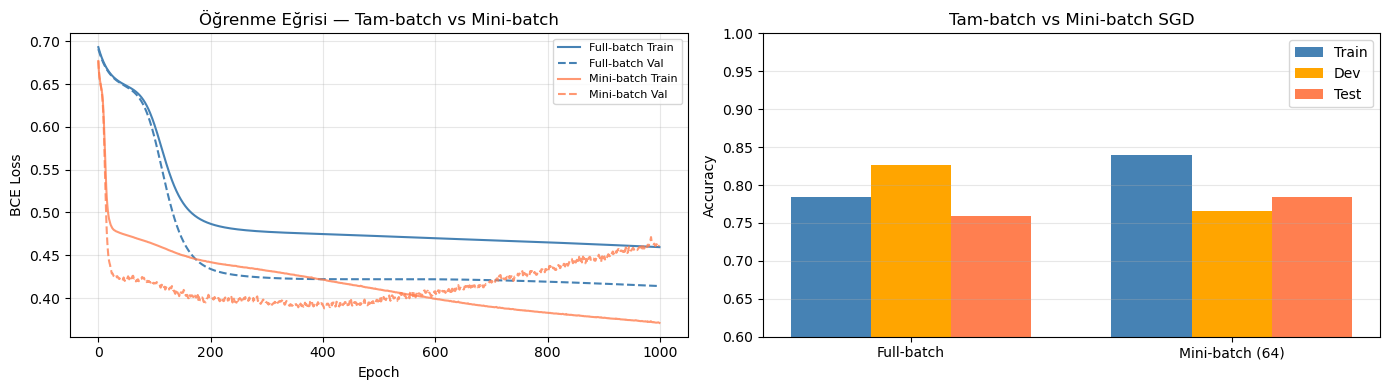

Full-batch  | Train:0.7840 Dev:0.8261 Test:0.7586
Mini-batch  | Train:0.8399 Dev:0.7652 Test:0.7845


In [23]:
# Tam-batch vs Mini-batch SGD karşılaştırması
model_fb = MLP_1Hidden(
    n_x=X_train_s.shape[1], n_h=N_H_1, n_y=1,
    learning_rate=LR_1, n_steps=STEPS_1,
    hidden_activation='tanh', batch_size=None  # tam-batch
)
model_fb.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)

model_mb = MLP_1Hidden(
    n_x=X_train_s.shape[1], n_h=N_H_1, n_y=1,
    learning_rate=LR_1, n_steps=STEPS_1,
    hidden_activation='tanh', batch_size=64  # mini-batch
)
model_mb.fit(X_train_s, y_train, X_val=X_dev_s, Y_val=y_dev)

# Öğrenme eğrileri karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(model_fb.cost_history, label='Full-batch Train', color='steelblue', lw=1.5)
axes[0].plot(model_fb.val_cost_history, label='Full-batch Val', color='steelblue', ls='--', lw=1.5)
axes[0].plot(model_mb.cost_history, label='Mini-batch Train', color='coral', lw=1.5, alpha=0.8)
axes[0].plot(model_mb.val_cost_history, label='Mini-batch Val', color='coral', ls='--', lw=1.5, alpha=0.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Öğrenme Eğrisi — Tam-batch vs Mini-batch')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Accuracy karşılaştırması
labels = ['Full-batch', 'Mini-batch (64)']
tr_accs = [model_fb.score(X_train_s, y_train), model_mb.score(X_train_s, y_train)]
dv_accs = [model_fb.score(X_dev_s, y_dev),     model_mb.score(X_dev_s, y_dev)]
ts_accs = [model_fb.score(X_test_s, y_test),   model_mb.score(X_test_s, y_test)]

x = np.arange(2); w = 0.25
axes[1].bar(x - w, tr_accs, w, label='Train', color='steelblue')
axes[1].bar(x,     dv_accs, w, label='Dev',   color='orange')
axes[1].bar(x + w, ts_accs, w, label='Test',  color='coral')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0.6, 1.0)
axes[1].set_title('Tam-batch vs Mini-batch SGD')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Full-batch  | Train:{tr_accs[0]:.4f} Dev:{dv_accs[0]:.4f} Test:{ts_accs[0]:.4f}')
print(f'Mini-batch  | Train:{tr_accs[1]:.4f} Dev:{dv_accs[1]:.4f} Test:{ts_accs[1]:.4f}')


---
## Özet

| Gereksinim | Durum |
|---|---|
| İkili sınıflandırma (Pima Diabetes) | ✅ |
| Veri analizi ve ön işleme | ✅ |
| 1 gizli katmanlı model — class yapısı | ✅ `MLP_1Hidden` |
| `_BaseMLPNumpy` kalıtımı (kod tekrarı yok) | ✅ |
| Dev set ile overfitting / underfitting analizi | ✅ |
| Geniş model + 2 gizli katman + L2 regularizasyon | ✅ M2–M5 |
| Grid search — test seti kullanılmaz | ✅ |
| **Veri miktarı etkisi (%50/%75/%100)** | ✅ Bölüm 7 |
| Sklearn MLPClassifier (öğrenme eğrisi dahil) | ✅ |
| PyTorch MLP | ✅ |
| Confusion matrix + accuracy, precision, recall, F1 | ✅ Her model |
| Modüler dosya yapısı (`src/`) | ✅ |
| ROC eğrisi + AUC skoru | ✅ Bölüm 11 |
| Mini-batch SGD karşılaştırması | ✅ Bölüm 12 |
| Numerik stabilite (sigmoid clip) | ✅ `_BaseMLPNumpy._sigmoid` |
